# 06 - Model comparison

Bring together every model and evaluation mode: the cold-start GroupKFold
comparison from notebooks 04/05, plus a temporal-holdout comparison of the
slope estimators themselves (OLS, Theil-Sen, MixedLM BLUP, MixedLM
population-only) predicting each participant's actual next visit from their
own history.

In [1]:
import sys
sys.path.append("..")

import os
import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing import load_data, validate_longitudinal
from src.evaluation.evaluation import compare_all, evaluate_temporal_holdout
from src.visualisation.visualisation import plot_model_comparison


In [2]:
linear_results_df = pd.read_csv("../data/processed/linear_model_results.csv")
nonlinear_results_df = pd.read_csv("../data/processed/nonlinear_model_results.csv")

# baseline_mean is computed independently in both notebooks 04 and 05 (each
# is meant to stand alone) - drop the duplicate rows here before comparing.
cross_participant_results = pd.concat([linear_results_df, nonlinear_results_df], ignore_index=True)
cross_participant_results = cross_participant_results.drop_duplicates(subset=["model", "mode", "domain"])
cross_participant_results


,model,mode,mae,rmse,r2,n,domain
0,baseline_mean,cross_participant,0.060712,0.075489,-0.004900,250,memory
1,ridge,cross_participant,0.054412,0.066810,0.212904,250,memory
2,baseline_mean,cross_participant,0.041327,0.051553,-0.001703,250,attention
3,ridge,cross_participant,0.041505,0.051606,-0.003762,250,attention
4,baseline_mean,cross_participant,0.035957,0.043218,-0.004245,250,language
5,ridge,cross_participant,0.034383,0.042255,0.040024,250,language
7,random_forest,cross_participant,0.055148,0.069319,0.152657,250,memory
8,gbr,cross_participant,0.059370,0.073905,0.036832,250,memory
10,random_forest,cross_participant,0.044151,0.054065,-0.101721,250,attention
11,gbr,cross_participant,0.047592,0.058046,-0.269913,250,attention


In [3]:
sim_df = validate_longitudinal(load_data("../data/simulated/longitudinal_simulated.csv"))

temporal_results = []
for domain in ("memory", "attention", "language"):
    result = evaluate_temporal_holdout(sim_df, value_col=domain)
    result["domain"] = domain
    temporal_results.append(result)

temporal_holdout_results = pd.concat(temporal_results, ignore_index=True)
temporal_holdout_results


c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 444.382103
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive defi

c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 373.855392
  warnings.warn(msg, ConvergenceWarning)
c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive defi

c:\Users\yusef\Downloads\Cognitive-Decline-Prediction-main\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,model,mode,mae,rmse,r2,n,domain
0,ols,temporal_holdout,0.866303,1.111536,0.903835,250,memory
1,theilsen,temporal_holdout,0.961686,1.233364,0.881600,250,memory
2,mixedlm_blup,temporal_holdout,0.856704,1.110694,0.903981,250,memory
3,mixedlm_population_only,temporal_holdout,2.454471,3.031961,0.284488,250,memory
4,ols,temporal_holdout,3.342207,4.249116,0.760741,250,attention
5,theilsen,temporal_holdout,3.681591,4.633077,0.715547,250,attention
6,mixedlm_blup,temporal_holdout,11.102422,11.653198,-0.799542,250,attention
7,mixedlm_population_only,temporal_holdout,11.099333,11.681497,-0.808293,250,attention
8,ols,temporal_holdout,2.097125,2.683282,0.853793,250,language
9,theilsen,temporal_holdout,2.195294,2.793615,0.841523,250,language


In [4]:
comparison_df = compare_all(cross_participant_results, temporal_holdout_results)
os.makedirs("../data/processed", exist_ok=True)
comparison_df.to_csv("../data/processed/model_comparison.csv", index=False)
comparison_df


,model,mode,mae,rmse,r2,n,domain
0,ridge,cross_participant,0.034383,0.042255,0.040024,250,language
1,random_forest,cross_participant,0.034833,0.043172,-0.002132,250,language
2,gbr,cross_participant,0.035825,0.045052,-0.091313,250,language
3,baseline_mean,cross_participant,0.035957,0.043218,-0.004245,250,language
4,baseline_mean,cross_participant,0.041327,0.051553,-0.001703,250,attention
5,ridge,cross_participant,0.041505,0.051606,-0.003762,250,attention
6,random_forest,cross_participant,0.044151,0.054065,-0.101721,250,attention
7,gbr,cross_participant,0.047592,0.058046,-0.269913,250,attention
8,ridge,cross_participant,0.054412,0.066810,0.212904,250,memory
9,random_forest,cross_participant,0.055148,0.069319,0.152657,250,memory


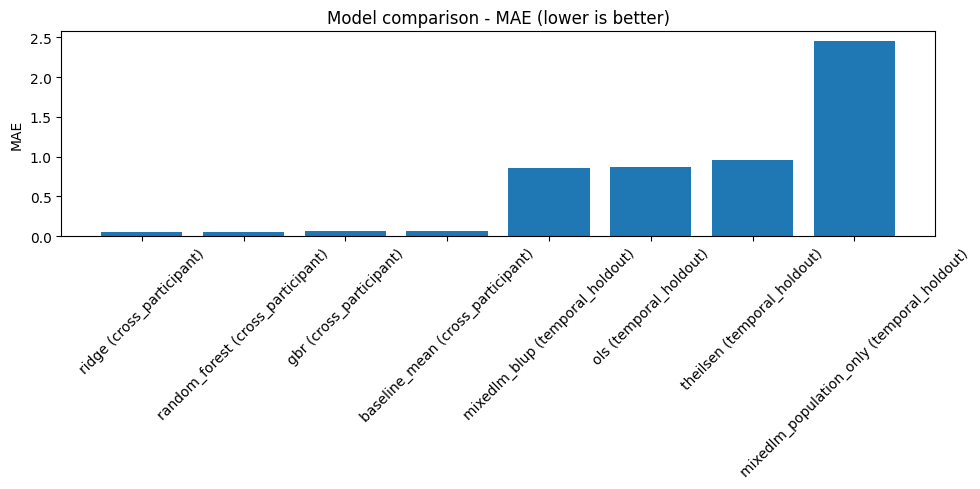

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_model_comparison(comparison_df[comparison_df["domain"] == "memory"], metric="mae", ax=ax)
plt.tight_layout()
plt.show()


## Discussion

With n=250 simulated participants and decline rates that are mostly driven by
per-person random noise (see `notebooks/00_generate_simulated_data.ipynb`),
expect the naive population-mean baseline to already be fairly competitive:
ML models (Ridge/RF/GBR) can only improve on it to the extent that
demographics and early-visit slope/variability features genuinely carry
signal about a person's true decline rate. If `random_forest`/`gbr` beat
`baseline_mean` only marginally, that is an expected/honest result given the
generative design, not a bug. In the temporal-holdout comparison,
`mixedlm_blup` is expected to outperform independent `ols`/`theilsen` most
clearly for participants with few visits (heavier dropout), since it borrows
statistical strength from the rest of the cohort.